In [1]:
# === FINAL 1D-CNN + BiGRU Pipeline for FHR_denoised + UC ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [2]:
# === STEP 0: Configuration ===
segment_length = 1200
segmented_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/1D-CNN-UC-FHR'


In [ ]:
# MAIN SEGMENTATION CODE
"""
label_df = pd.read_csv(label_file)
label_df['ID'] = label_df['ID'].astype(str)
label_dict = dict(zip(label_df['ID'], label_df['target']))

os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, 'class_0'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'class_1'), exist_ok=True)

for filename in os.listdir(source_dir):
    if filename.endswith('.csv'):
        patient_id = filename.split('.')[0]
        if patient_id not in label_dict:
            continue

        df = pd.read_csv(os.path.join(source_dir, filename))
        if 'FHR_denoised' not in df.columns or 'UC' not in df.columns:
            continue

        total_samples = len(df)
        num_segments = min(max_segments, total_samples // segment_length)

        for i in range(num_segments):
            segment = df.iloc[i * segment_length:(i + 1) * segment_length][['FHR_denoised', 'UC']]
            if segment.shape[0] == segment_length:
                label = label_dict[patient_id]
                class_folder = os.path.join(output_dir, f'class_{label}')
                save_path = os.path.join(class_folder, f'{patient_id}_segment_{i+1}.csv')
                segment.to_csv(save_path, index=False)

print("✅ Segmentation complete")
"""

✅ Segmentation complete


In [3]:
# === STEP 1: Load and Normalize Data ===
X, y = [], []
for class_label in ['class_0', 'class_1']:
    label = int(class_label.split('_')[1])
    path = os.path.join(segmented_dir, class_label)
    for file in os.listdir(path):
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(path, file))
            if 'FHR_denoised' not in df.columns or 'UC' not in df.columns:
                continue
            signal = np.stack([df['FHR_denoised'].values, df['UC'].values], axis=1)
            if signal.shape != (segment_length, 2):
                continue
            for i in range(2):
                col = signal[:, i]
                if np.max(col) - np.min(col) != 0:
                    signal[:, i] = (col - np.min(col)) / (np.max(col) - np.min(col))
            X.append(signal)
            y.append(label)

In [4]:
X = np.array(X)
y = np.array(y)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [5]:
# === STEP 2: Build CNN + BiGRU Model ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, GRU, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv1D(64, kernel_size=5, activation='relu', input_shape=(segment_length, 2)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Bidirectional(GRU(64, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1196, 64)          704       
                                                                 
 batch_normalization (BatchN  (None, 1196, 64)         256       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 598, 64)          0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 598, 64)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 596, 128)          24704     
                                                                 
 batch_normalization_1 (Batc  (None, 596, 128)         5

In [6]:
# === STEP 3: Callbacks + Class Weight ===
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6)
]

In [7]:
# === STEP 4: Train ===
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/50
191/191 [==============================] - 44s 207ms/step - loss: 0.7331 - accuracy: 0.5043 - val_loss: 0.6133 - val_accuracy: 0.7937 - lr: 5.0000e-04
Epoch 2/50
191/191 [==============================] - 39s 202ms/step - loss: 0.7126 - accuracy: 0.5251 - val_loss: 0.5840 - val_accuracy: 0.7989 - lr: 5.0000e-04
Epoch 3/50
191/191 [==============================] - 39s 202ms/step - loss: 0.7081 - accuracy: 0.5250 - val_loss: 0.6578 - val_accuracy: 0.6281 - lr: 5.0000e-04
Epoch 4/50
191/191 [==============================] - 38s 200ms/step - loss: 0.7015 - accuracy: 0.5253 - val_loss: 0.6764 - val_accuracy: 0.5966 - lr: 5.0000e-04
Epoch 5/50
191/191 [==============================] - 39s 203ms/step - loss: 0.6952 - accuracy: 0.5284 - val_loss: 0.6649 - val_accuracy: 0.6531 - lr: 2.5000e-04
Epoch 6/50
191/191 [==============================] - 39s 203ms/step - loss: 0.6944 - accuracy: 0.5516 - val_loss: 0.6684 - val_accuracy: 0.6393 - lr: 2.5000e-04
Epoch 7/50
191/191 [========

In [8]:
# === STEP 5: Evaluation ===
y_scores = model.predict(X_val).flatten()

best_thresh = 0.5
best_f1 = 0
for t in np.arange(0.1, 0.9, 0.01):
    preds = (y_scores > t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_thresh = t
        best_f1 = f1

print(f"\n=== Best Threshold by F1: {best_thresh:.2f} ===")
y_pred = (y_scores > best_thresh).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred, digits=4))

48/48 [==============================] - 2s 38ms/step

=== Best Threshold by F1: 0.45 ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.6667    0.0068    0.0135       293
           1     0.8084    0.9992    0.8937      1229

    accuracy                         0.8081      1522
   macro avg     0.7375    0.5030    0.4536      1522
weighted avg     0.7811    0.8081    0.7243      1522



In [9]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))


Confusion Matrix:
[[   2  291]
 [   1 1228]]


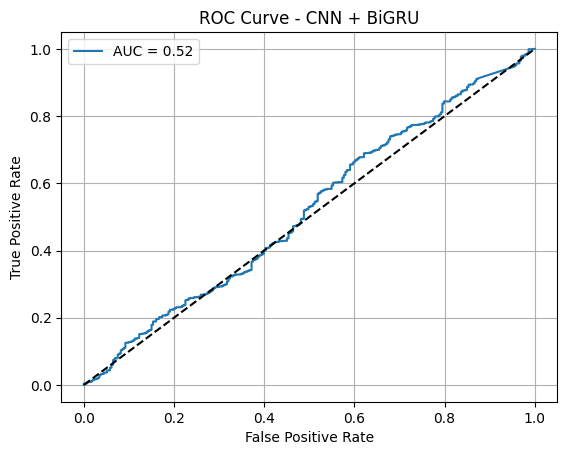

In [10]:
# === STEP 6: ROC Curve ===
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN + BiGRU')
plt.legend()
plt.grid(True)
plt.show()

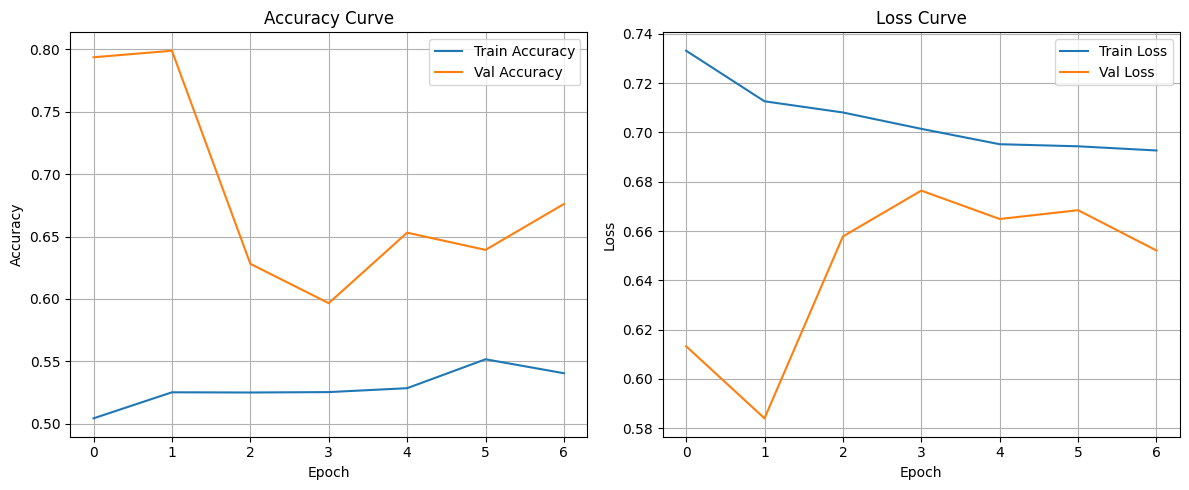

In [11]:
# === STEP 7: Accuracy & Loss Curves ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()